# <a id='toc1_'></a>[Aging Aware Energy Management for RMCES](#toc0_)
*Case Study II: NMC vs LFP*
<br>*By: Dario Slaifstein, PhD Candidate*
<br> Group: DCES
<br> Project: **FLEXINet**
<br> Result: 6

Source control
- Branch: `rev_`
- version: `2.0`
- Date: 8/04/2026

**Table of contents**<a id='toc0_'></a>    
- [Aging Aware Energy Management for RMCES](#toc1_)    
  - [Modeling the system](#toc1_1_)    
  - [General workflow](#toc1_2_)    
    - [Input data](#toc1_2_1_)    
- [Case study 2 - Chemistry comparison](#toc2_)    
  - [Dispatch analysis](#toc2_1_)    
    - [BESS](#toc2_1_1_)    
    - [EV](#toc2_1_2_)    
    - [TESS](#toc2_1_3_)    
    - [Grid](#toc2_1_4_)    
  - [2D Histograms](#toc2_2_)    
  - [Degradation analysis](#toc2_3_)    
  - [Cost analysis functions](#toc2_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
# Import all the necessary packages
using JuMP, InfiniteOpt, KNITRO, LiiBRA, EMSmodule, ColorSchemes
using LinearAlgebra, Distributions, Statistics, Parameters, Random, Revise
using DataFrames, LaTeXStrings, Printf, JSON3, GLMakie, CairoMakie, Makie

Random.seed!(1234);
includet("../functions/build_data.jl") # data structures

## <a id='toc1_1_'></a>[Modeling the system](#toc0_)
---
The FLEXINet project can be seen in the following image:

![Flexinet Concept](../images/grabs_AppEnergy.png)

This notebook reproduces the results of the Case Study 2 of the journal. The main objective is to compare the aging of two different chemistries, NMC and LFP, in a residential multi-carrier energy system (RMCES). The LFP cell chemistry is known for its long cycle life, while the NMC cell chemistry is known for its high energy density. The comparison is made in two different scenarios, winter and summer, to evaluate the impact of the season on the aging of the cells and grid costs.

The LFP cell is modeled using the dataset from [Prada (2013)](https://iopscience.iop.org/article/10.1149/2.053304jes) and the NMC cell is modeled using the SANYO cell of [Jin (2022)](https://linkinghub.elsevier.com/retrieve/pii/S0013468621019356).

## <a id='toc1_2_'></a>[General workflow](#toc0_)
---
### <a id='toc1_2_1_'></a>[Input data](#toc0_)
Each component has their own structure, which contains params and so on. Then all the objects are saved in a dictionary called `EMSData`.
The following timeseries are used as input for the model:
- Auction prices from EPEX
- Electric demand $P_{load}^{e}$
- Thermal demand $P_{load}^{t}$
- Solar MPPT measurements $P_{PV, MPPT}$

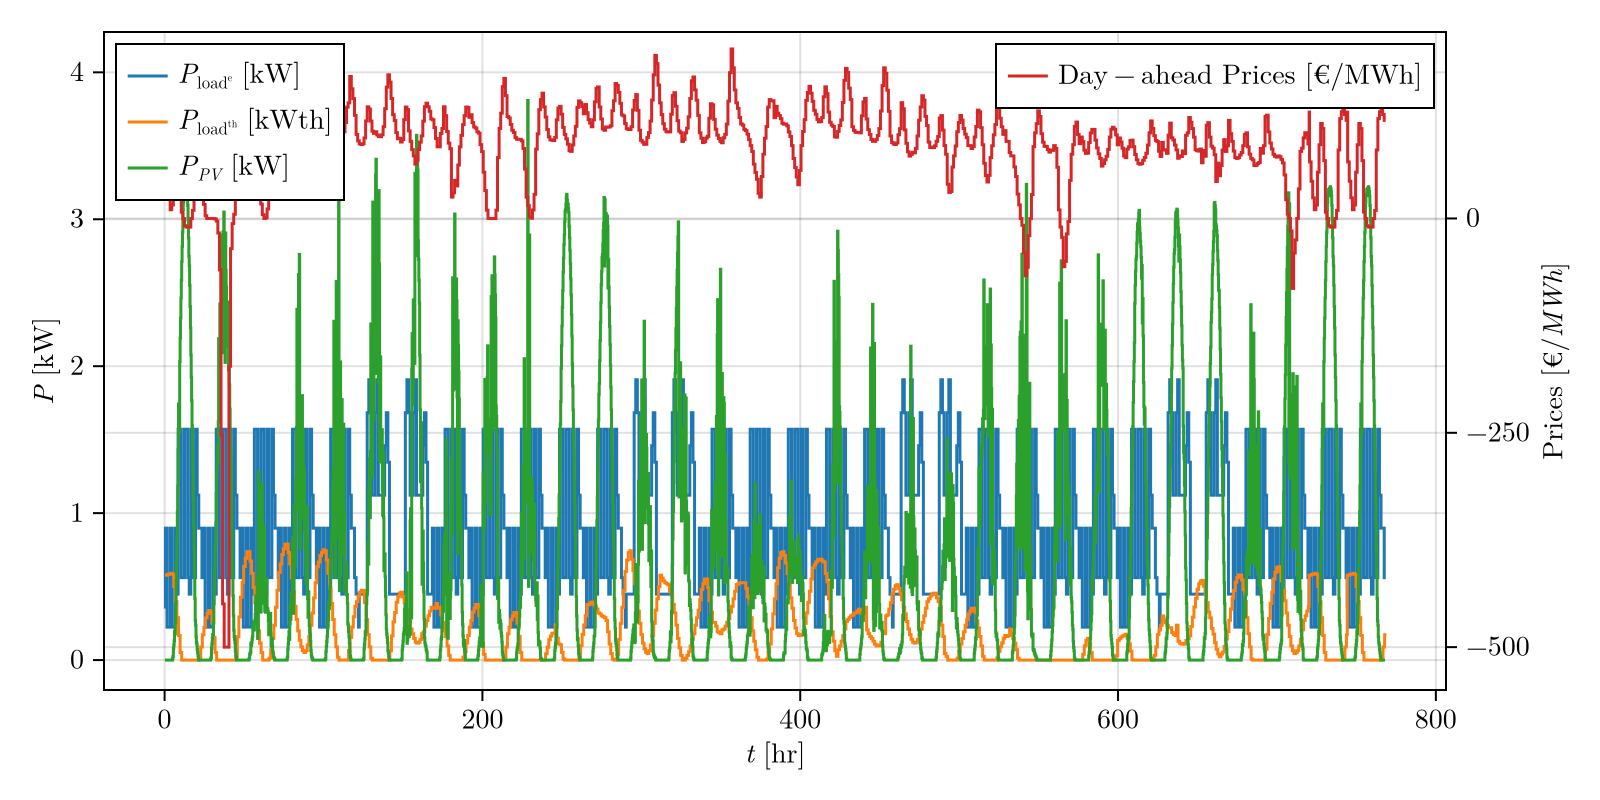

In [2]:
EMSData=build_data(;nEV=1, season="summer", profType="monthly", loadType="GV", year=2023);
makeInputsplot(EMSData["grid"], EMSData["SPV"])

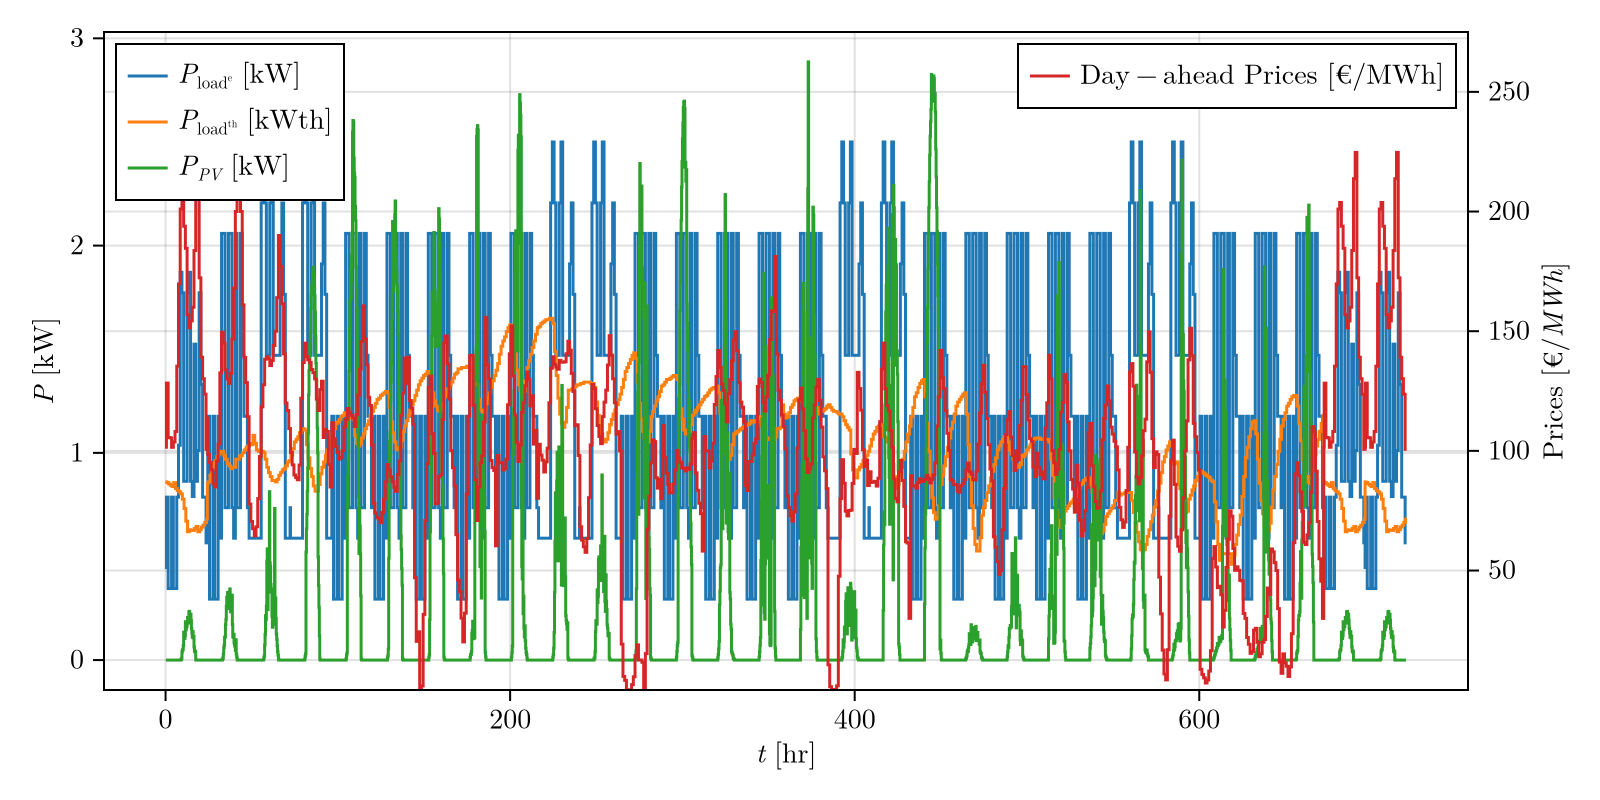

In [3]:
EMSData=build_data(;nEV=1, season="winter", profType="monthly", loadType="GV", year=2023);
makeInputsplot(EMSData["grid"], EMSData["SPV"])

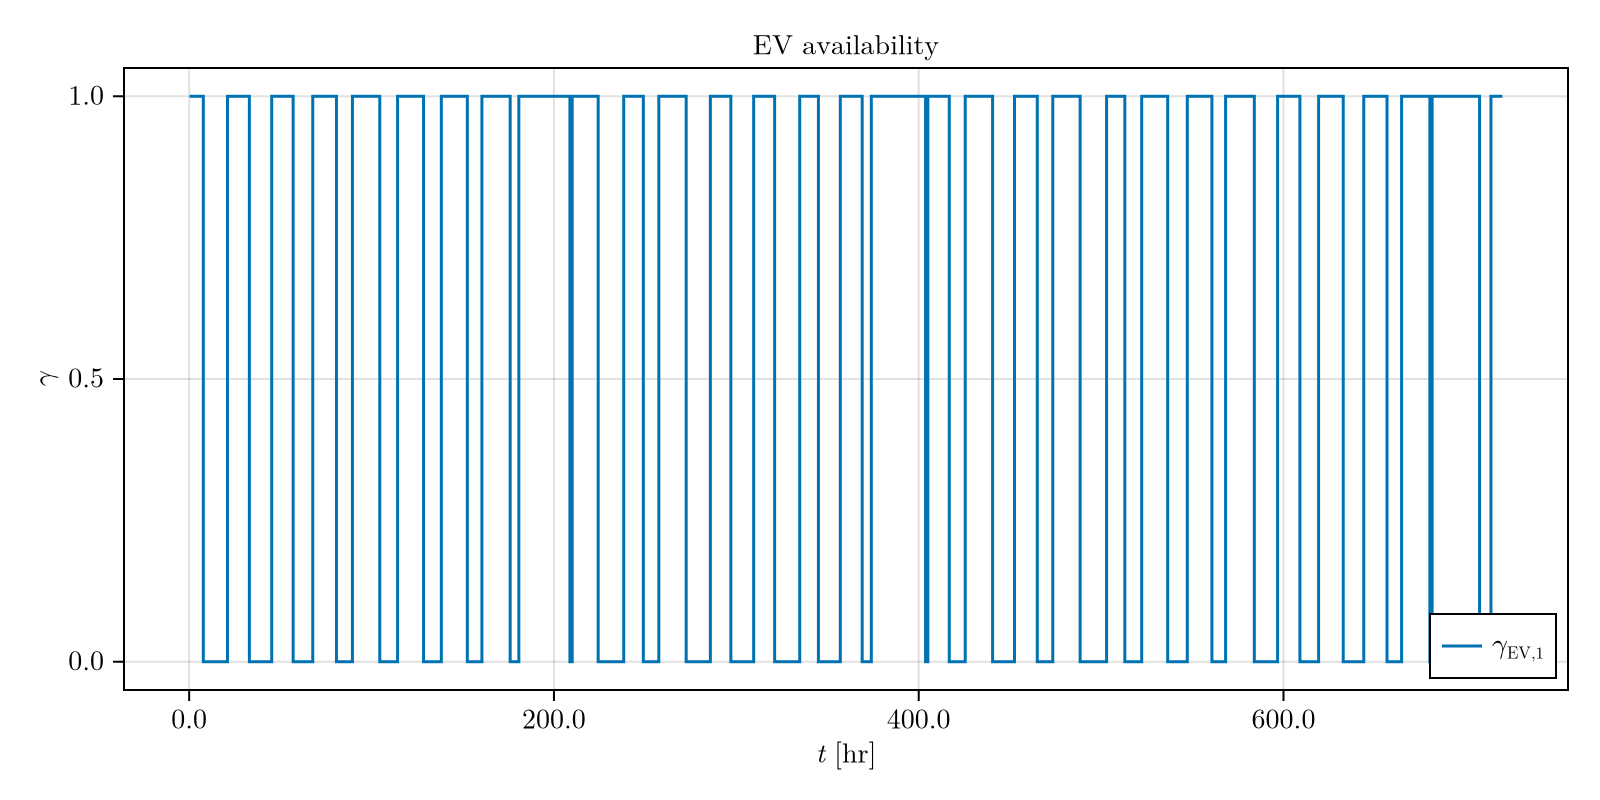

In [4]:
CairoMakie.activate!(type="svg")
# GLMakie.activate!()
f=Figure(size=(800, 400))
colors=ColorSchemes.tab10.colors;
ax1=Axis(f[1,1];
        title = L"\textrm{EV availability}",
        xlabel=L"$t$ [hr]", ylabel=L"$\gamma$",
        ytickformat = values -> [L"%$(value)" for value in values],
        xtickformat = values -> [L"%$(value)" for value in values],
        )
[stairs!(ax1,(1:length(EMSData["EV"][n].driveInfo.γ))./4,EMSData["EV"][n].driveInfo.γ, 
         label=L"\gamma_{\textrm{EV}, %$n}") for n ∈ 1:length(EMSData["EV"])]
axislegend(ax1, position=:rb)
f

# <a id='toc2_'></a>[Case study 2 - Chemistry comparison](#toc0_)
- **BNoDeg** Bucket Model with NO degradation
- **CPBDeg** Equivalent Circuit Model with Physics-based degradation

Plotting functions.
- `create_Pfig` plots timeseries signals against time.
- `create_SPfig` plots 2D histograms of $P$ vs $SoC$.
- `create_FECQlossfig` plots $Q_{\textrm{loss},t}$, $FEC_t$ and $Q_{\textrm{loss}}$ vs $FEC_t$.

Figure definition

In [2]:
# function defs
function create_Pfig(results, P_key, label; backend::String="GLMakie", filename::String="fig.png")
    @assert backend ∈ ["CairoMakie", "GLMakie"] "backend must be either CairoMakie or GLMakie"
    if backend == "CairoMakie"
        CairoMakie.activate!(type = "svg")
    else
        GLMakie.activate!()
    end
    
    set_theme!(theme_latexfonts(), fontsize = 20)
    f=Figure(size=(800, 600))
    # colors=ColorSchemes.tab10.colors;
    colors=ColorSchemes.Dark2_7.colors;
    ax1=Axis(f[1,1];
            # title = L"\textrm{Summer}",
            xlabel=L"$t$ [hr]", ylabel=label,
            xautolimitmargin = (0, 0), yautolimitmargin = (0.05, 0.15),
            )
    ax2=Axis(f[2,1];
            # title = L"\textrm{Winter}",
            xlabel=L"$t$ [hr]", ylabel=label,
            xautolimitmargin = (0, 0), yautolimitmargin = (0.05, 0.15),
            )
    axes = [ax1, ax2]
    
    # loop over the season
    for (j,season) ∈ enumerate([:summer, :winter])
        # loop over the DAtype
        for (i, cath) ∈ enumerate([:LFP, :NMC])
            # concRes = concatResultsFlex(results[season][Symbol(cath)], CT_MPC())
            concRes = results[season][Symbol(cath)]
            t = convert.(Float64, concRes["t"])
            Psa = convert.(Float64, concRes[P_key])
            γ_cont = concRes[:"γf"][:]
            
            stairs!(axes[j], t./3600, Psa, color=colors[i], label="$cath", linewidth=2, step=:post)
            iArr = findall(x -> x == 1, diff(γ_cont))
            # departure when γ_cont changes from 1 to 0
            iDep = findall(x -> x == -1, diff(γ_cont))
            # check if they are the same length.
            iDep = Int.(iDep); iArr = Int.(iArr);
            vspan!(axes[j], t[iDep]/3600, t[iArr]/3600, ymax=100, color = (:grey, 0.15))
            limits!(axes[j], t[1]/3600, t[end]/3600, nothing, nothing);
        end
    end
    textlabel!(ax1, 530, 1., text= "Summer", fontsize = 18)
    textlabel!(ax2, 530, .4, text= "Winter", fontsize = 18)
    # axislegend(ax1, position=:rb)
    hidexdecorations!(ax1, grid = false)
    axislegend(ax2, position=:rt)
    if backend == "CairoMakie"
        save(filename, f)
        return f
    else
        return display(GLMakie.Screen(), f)
    end
end

function create_SPfig(results, key;
                    backend::String="GLMakie",
                    filename::String="fig.png",
                    cmaps::Symbol=:balance,
                    lims=([-7.5, 7.5], [0.2, 0.8]), # xmin xmax ymin ymax
                    nb::Int=50,
                    )
    @assert backend ∈ ["CairoMakie", "GLMakie"] "backend must be either CairoMakie or GLMakie"
    if backend == "CairoMakie"
        CairoMakie.activate!(type = "svg")
    else
        GLMakie.activate!()
    end

    set_theme!(theme_latexfonts())
    f=Figure(size=(600, 500))
    axes=[];

    # setup keys
    SoC_key = "SoC$key";
    key == "ev[1]" ? key = "evTot[1]" : nothing;
    P_key = "P$key";
    
    # loop over the season
    for (j,season) ∈ enumerate([:summer, :winter])
        # loop over the DAtype
        for (i, cath) ∈ enumerate([:LFP, :NMC])
            # concRes = concatResultsFlex(results[season][Symbol(cath)], CT_MPC())
            concRes = results[season][Symbol(cath)]
            Psa = convert.(Float64, concRes[P_key])
            SoCsa = convert.(Float64, concRes[SoC_key])
            if key == "evTot[1]"
                # exclude the points where the EV is not connected
                γ_cont = concRes[:"γf"][:]
                Psa = Psa[γ_cont .== 1];
                SoCsa = SoCsa[γ_cont .== 1];
            end
            ax = Axis(f[j,i];
                xlabel=L"$P$ [kW]", ylabel=L"$SoC$ [p.u.]",
                )
            # Create a 2D histogram
            histogram, xedges, yedges = hist2d(Psa, SoCsa; nbins=nb, normalize=true)
            co = contourf!(ax, xedges[2:end], yedges[2:end], histogram,
                        levels=0.01:0.1:1, colormap=cmaps, mode = :relative, label = "$cath")
            # limits!(ax, -7.5, 7.5, 0.2, 0.8);
            limits!(ax, lims[1][1], lims[1][2], lims[2][1], lims[2][2]);
            j == 1 ? hidexdecorations!(ax, grid = false) : nothing;
            j == 2 ? Colorbar(f[j+1,i], co, vertical = false) : nothing;
            i == 1 ? nothing : hideydecorations!(ax, grid = false);
            push!(axes, ax)
            axislegend(ax, position=:rb)
        end
    end
    Label(f[1, 1:end, Top()], "Summer", valign = :bottom,
        font = :bold,
        padding = (0, 0, 5, 0))
    Label(f[2, 1:end, Top()], "Winter", valign = :bottom,
        font = :bold,
        padding = (0, 0, 5, 0))

    if backend == "CairoMakie"
        save(filename, f)
        return f
    else
        return display(GLMakie.Screen(), f)
    end
end

function plot_powerLims(results_DA, ctrl_DA, keys, lims)
    GLMakie.activate!()
    set_theme!(theme_latexfonts())
    f = Figure()
    colors = Makie.wong_colors()
    
    for (i, season) in enumerate([:summer, :winter])
        ax = Axis(f[i, 1]; title = season == :summer ? "Summer" : "Winter", xlabel = "t [hr]", ylabel = "P [kW]")
        t = convert.(Float64, results_DA[season][:LFP]["t"]) / 3600
        for (j, key) ∈ enumerate(keys)
            stairs!(ax, t, results_DA[season][:LFP][key],
            color = colors[j], label = "rlt", linewidth = 2, step = :post)
            idx = abs.(results_DA[season][:LFP][key]) .> lims[j]
            scatter!(ax, t[idx], results_DA[season][:LFP][key][idx],
            color = colors[6], label = "rlt", marker = :diamond, markersize = 10)
            stairs!(ax, t, ctrl_DA[season][:LFP][key],
            color = (colors[j], 0.7), label = "ctrl", linewidth = 2, step = :post, linestyle = :dash)
            axislegend(ax, position = :rb)
        end
    end
    
    return f
end

function create_FECQlossfig(results;
    backend::String="GLMakie",
    filename::String="fig.png")
    @assert backend ∈ ["CairoMakie", "GLMakie"] "backend must be either CairoMakie or GLMakie"
    if backend == "CairoMakie"
        CairoMakie.activate!(type = "svg")
    else
        GLMakie.activate!()
    end
    set_theme!(theme_latexfonts())
    f=Figure(size=(800, 300))
    colors=ColorSchemes.Dark2_7.colors;
    ax31=Axis(f[1,1]; ylabel = L"$Q_{\textrm{loss}}$ [%]",
            xlabel = L"$FEC$",
            );
    ax32=Axis(f[1,2];
            xlabel = L"$FEC$", 
            )
    ax=[ax31 ax32]
    markers = [:circle, :diamond]
    step = 150
    for (i,season) ∈ enumerate(keys(results))
        for (j, cath) ∈ enumerate([:LFP, :NMC])
            # result_vector = results[season][Symbol(cath)]
            # concRes = concatResultsFlex(result_vector, CT_MPC())
            concRes = results[season][Symbol(cath)]
            t = convert.(Float64, concRes["t"]); Δt = t[2] - t[1]
            for (d, sa) ∈ enumerate(["bess","ev[1]"])
                    Qsa = convert.(Float64, concRes["Q$sa"])
                    Qsa0 = Qsa[1]
                    isa = convert.(Float64, concRes["i$sa"])
                    FECsa = cumsum(abs.(isa)) .* Δt / 3600 / (2 * Qsa0)
                    sa == "bess" ? salbl = "BESS" : salbl = "EV"
                    # Qsa vs FEC
                    stairs!(ax[1,i], FECsa, (Qsa .- Qsa0)/Qsa0,
                            color=colors[j], label="$cath",
                            linewidth=2, step=:post,
                            )
                    scatter!(ax[1,i], FECsa[1:step:end], (Qsa[1:step:end] .- Qsa0)./Qsa0,
                            color=(colors[j], 0.5), label="$salbl",
                            marker = markers[d], markersize=15,
                            strokecolor = colors[j], 
                            )
            end
            # limits!.(ax[1,:], nothing, nothing, nothing, nothing)
        end
    end
    linkyaxes!(ax[1,1], ax[1,2]);
    hideydecorations!(ax[1,2], grid = false)
    # axislegend(ax[1,2], position=:rt, merge = true)
    # Legend(f[1,3],ax[1,1], position=:rb, merge = true)
    textlabel!(ax[1,1], 2, -1.2e-5, text = "Summer", fontsize = 15)
    textlabel!(ax[1,2], 2, -1.2e-5, text = "Winter", fontsize = 15)
    group_ch = [PolyElement(color = colors[j], strokecolor = :transparent) for j ∈ 1:2]
    group_sa = [MarkerElement(marker = mkr, color = (:gray, 0.5), strokecolor = :gray, markersize = 15) for mkr ∈ markers]

    legends = Legend(f[1,2],
        hcat([group_ch, group_sa]...)[:],
        ["LFP", "NMC", "BESS", "EV"],
        # [""],
        tellheight = false, tellwidth = false,
        halign = :right, valign = :top,
        # nbanks = 2,
        # orientation = :horizontal,
        margin = (5,5,5,5),
        )

    if backend == "CairoMakie"
            save(filename, f)
            return f
    else
            return display(GLMakie.Screen(), f)
    end
end

create_FECQlossfig (generic function with 1 method)

## <a id='toc2_1_'></a>[Dispatch analysis](#toc0_)

In [4]:
results_DA = Dict(:summer => Dict(:LFP => Dict{String, Any}(),
                                :NMC => Dict{String, Any}()),
                    :winter => Dict(:LFP => Dict{String, Any}(),
                                    :NMC => Dict{String, Any}()))
ctrl_DA = Dict(:summer => Dict(:LFP => Dict{String, Any}(),
                            :NMC => Dict{String, Any}()),
            :winter => Dict(:LFP => Dict{String, Any}(),
                            :NMC => Dict{String, Any}()))
folder = "../data/output/Run24/"
cells = ["A123", "SYNSANYO"]
for (j, season) ∈ enumerate([:summer, :winter])
    for (i, cath) ∈ enumerate([:LFP, :NMC])
        cellID = cells[i]
        sim = JSON3.read(open(folder * "cs1_R24_MPC_CPBDeg_W11e-2_$(cellID)_y2023$(String(season))d29.json", "r"), Dict{String, Vector{Dict}})["sim"]
        ctr = JSON3.read(open(folder * "cs1_R24_MPC_CPBDeg_W11e-2_$(cellID)_y2023$(String(season))d29.json", "r"), Dict{String, Vector{Dict}})["ctr"]
        results_DA[season][Symbol(cath)] = concatResultsFlex(sim, CT_MPC())
        ctrl_DA[season][Symbol(cath)] = concatResultsFlex(ctr, CT_MPC())
        # results_DA[season][Symbol(cath)] = JSON3.read(open(folder * "cs2_R24_MPC_CPBDeg_W11e-1_LFPvsNMC_$(String(season)).json", "r"), Dict{String, Dict})[cellID]["results"]
        # ctrl_DA[season][Symbol(cath)] = JSON3.read(open(folder * "cs2_R24_MPC_CPBDeg_W11e-1_LFPvsNMC_$(String(season)).json", "r"), Dict{String, Dict})[cellID]["controller"]
    end
end

Check power limits and constraints.

In [28]:
f=plot_powerLims(results_DA, ctrl_DA, ["Pbess", "PevTot[1]", "Pg"], [10., 12.5, 17.5])
display(GLMakie.Screen(), f)

GLMakie.Screen(...)

In [29]:
f=plot_powerLims(results_DA, ctrl_DA, ["Pg"], [17.5])
display(GLMakie.Screen(), f)

GLMakie.Screen(...)

In [4]:
results_DA

Dict{Symbol, Dict{Symbol, Vector{Dict}}} with 2 entries:
  :summer => Dict(:LFP=>[Dict{String, Any}("PtessPos"=>Any[0.612092, 0.612092, …
  :winter => Dict(:LFP=>[Dict{String, Any}("PtessPos"=>Any[0.843393, 0.843393, …

In [5]:
ctrl_DA

Dict{Symbol, Dict{Symbol, Vector{Dict}}} with 2 entries:
  :summer => Dict(:LFP=>[Dict{String, Any}("PtessPos"=>Any[0.612092, 0.612092, …
  :winter => Dict(:LFP=>[Dict{String, Any}("PtessPos"=>Any[0.843393, 0.843393, …

In [ ]:
GLMakie.activate!()
set_theme!(theme_latexfonts(), fontsize=12)
f = Figure()
colors=ColorSchemes.Dark2_7.colors;
for (j, season) ∈ enumerate(keys(results_DA))
    for (d, key) ∈ enumerate(["SoCbess", "SoCev[1]"])
        ax = Axis(f[j, d]; title = "$(String(season))", xlabel = "t [hr]", ylabel = "SoC [p.u.]")
        for (i, cath) ∈ enumerate([:LFP, :NMC])
            sim = concatResultsFlex(results_DA[season][Symbol(cath)], CT_MPC())
            ctrl = concatResultsFlex(ctrl_DA[season][Symbol(cath)], CT_MPC())
            t = convert.(Float64, sim["t"]) / 3600
            stairs!(ax, t, sim[key],
                    color = colors[i], label = "$(String(key))^+", linewidth = 2, step = :post)
            stairs!(ax, t, ctrl[key],
                    color = (colors[i], 0.7), label = "$(String(key))^-", linewidth = 2, step = :post,
                    linestyle = :dash)
            SoCmin = i == 1 ? 0.15 : 0.2
            idx_sim_min = (sim[key] .- SoCmin .≤ 1e-3)# idx in which SoC⁺ is in lower bound
            idx_rej = ctrl[key][idx_sim_min] .!= sim[key][idx_sim_min] # idx in which SoC⁻ is not in lower bound
            println("The % of rejection (SoC⁻ ≠ SoC⁺ == SoCmin) for $(String(season)) $(String(cath)) $(String(key)) is:")
            println(typeof(idx_rej) == BitVector ? sum(idx_rej)/length(sim[key])*100 : nothing)
        end
    end
end
f

The % of rejection (SoC⁻ ≠ SoC⁺ == SoCmin) for summer LFP SoCbess is:
40.122126436781606
0.15
The % of rejection (SoC⁻ ≠ SoC⁺ == SoCmin) for summer NMC SoCbess is:
31.573275862068968
0.2
The % of rejection (SoC⁻ ≠ SoC⁺ == SoCmin) for summer LFP SoCev[1] is:
1.4008620689655173
0.15
The % of rejection (SoC⁻ ≠ SoC⁺ == SoCmin) for summer NMC SoCev[1] is:
nothing
0.2
The % of rejection (SoC⁻ ≠ SoC⁺ == SoCmin) for winter LFP SoCbess is:
24.964080459770116
0.15
The % of rejection (SoC⁻ ≠ SoC⁺ == SoCmin) for winter NMC SoCbess is:
10.416666666666668
0.2
The % of rejection (SoC⁻ ≠ SoC⁺ == SoCmin) for winter LFP SoCev[1] is:
0.5028735632183908
0.15
The % of rejection (SoC⁻ ≠ SoC⁺ == SoCmin) for winter NMC SoCev[1] is:
0.3951149425287357
0.2


Need to run CPBDeg LFP in winter with the server.

### <a id='toc2_1_1_'></a>[BESS](#toc0_)

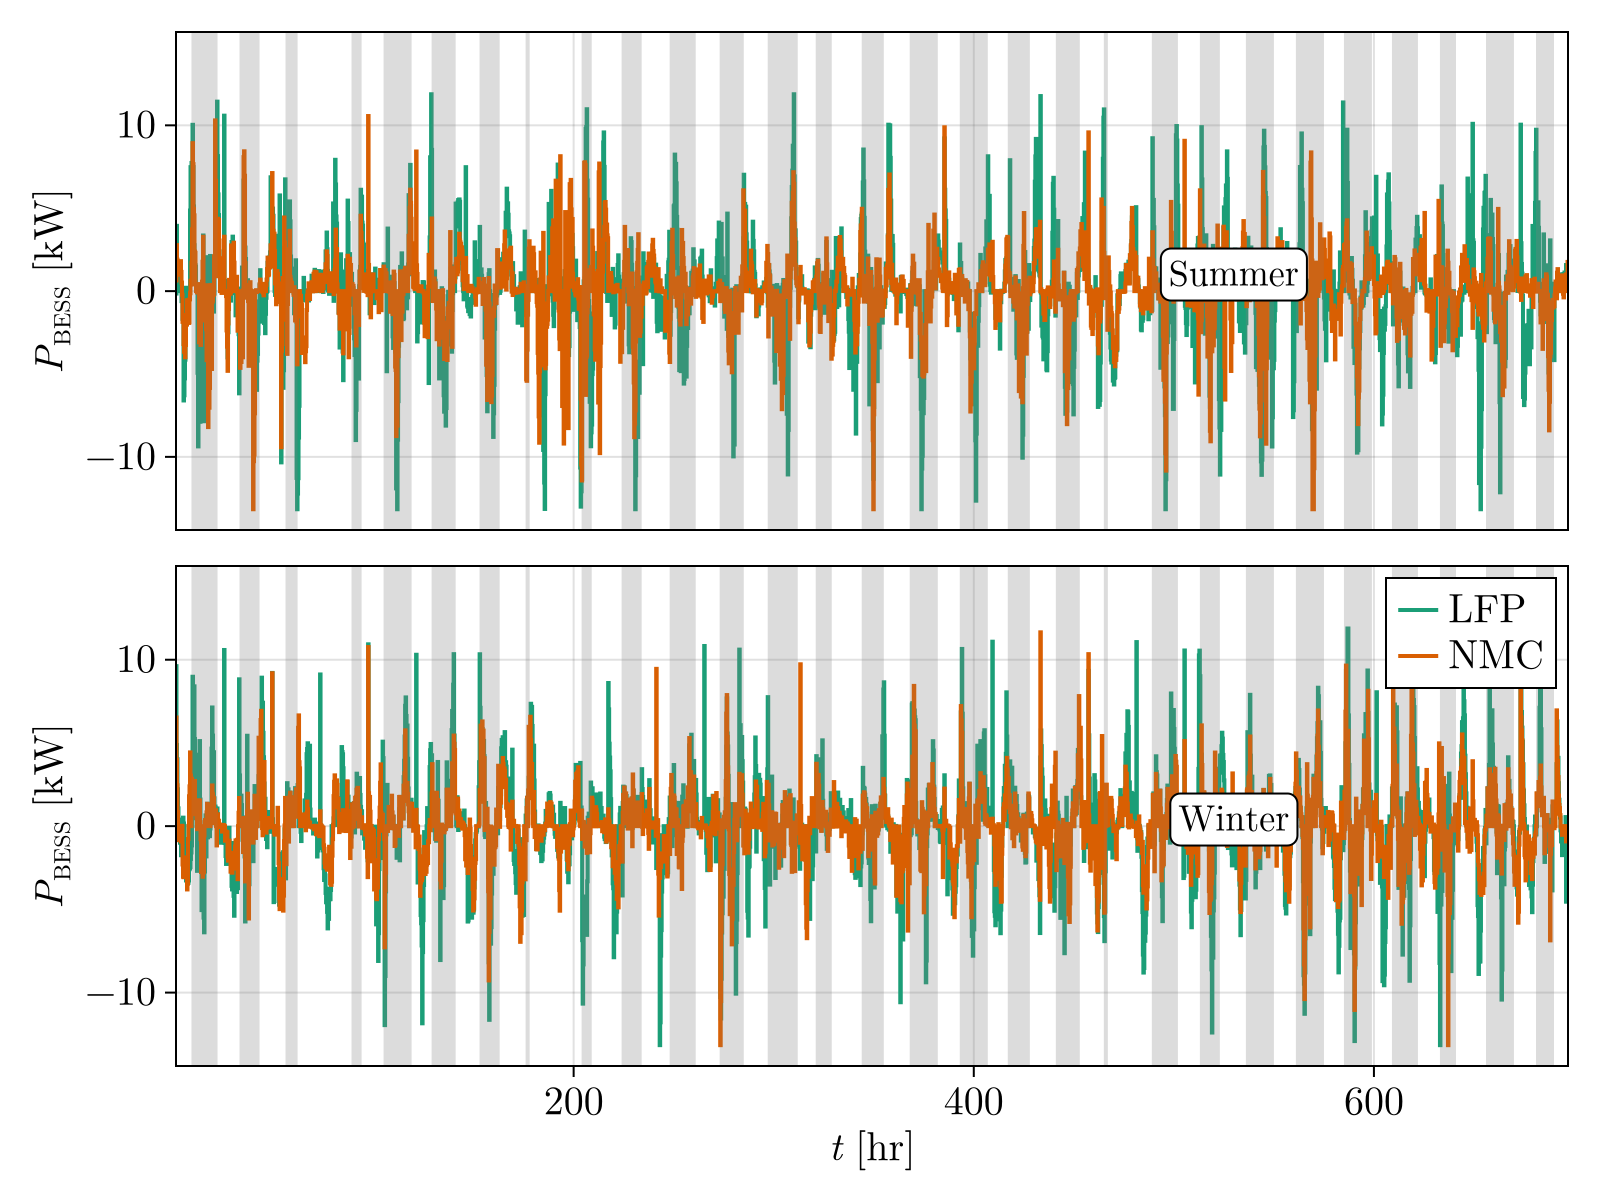

In [6]:
folder = "../images/AppEnergy/cs2/"; # relative path to the
label=L"$P_{\textrm{BESS}}$ [kW]"
P_key = "Pbess";filename="CS2_Pbess_LFPvsNMC.pdf"
create_Pfig(results_DA, P_key, label; backend="CairoMakie", filename=folder*filename)

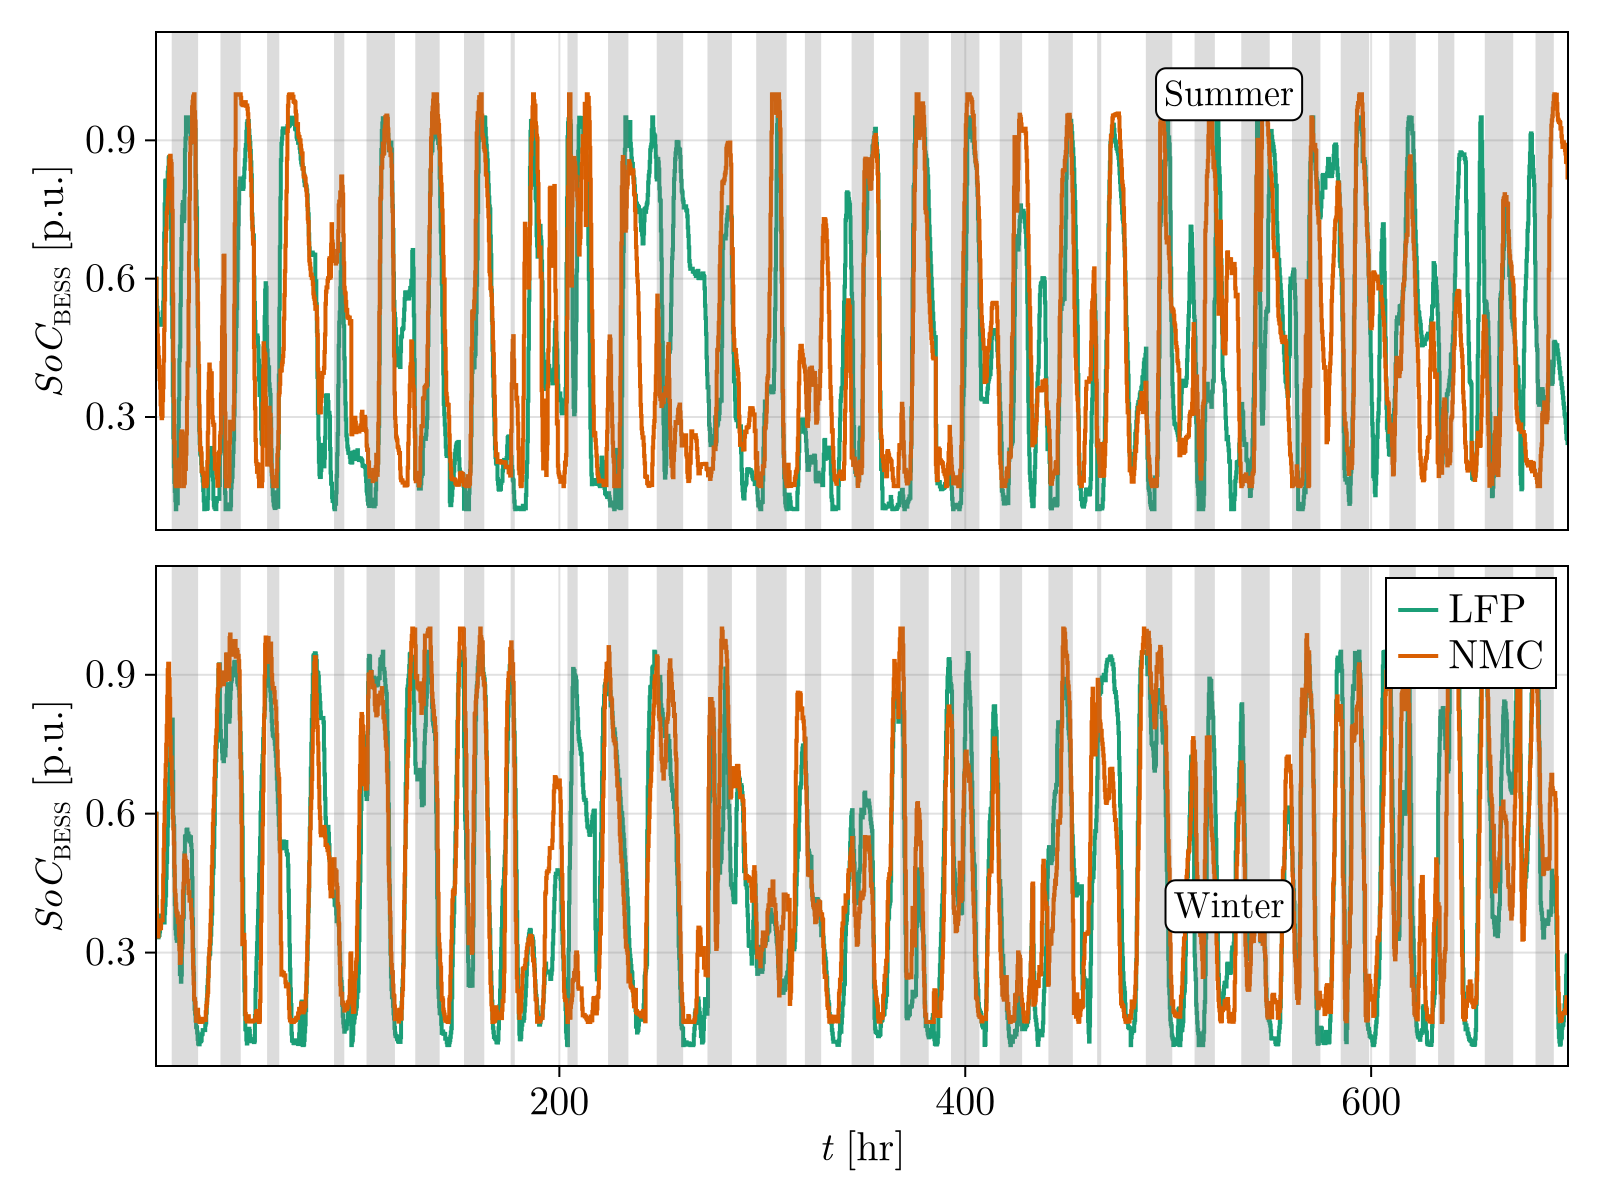

In [5]:
folder= "../images/AppEnergy/cs2/"; # relative path to the
label = L"$SoC_{\textrm{BESS}}$ [p.u.]"
P_key = "SoCbess"; filename="CS2_SoCbess_LFPvsNMC.pdf"
create_Pfig(results_DA, P_key, label; backend="CairoMakie", filename=folder*filename)

### <a id='toc2_1_2_'></a>[EV](#toc0_)

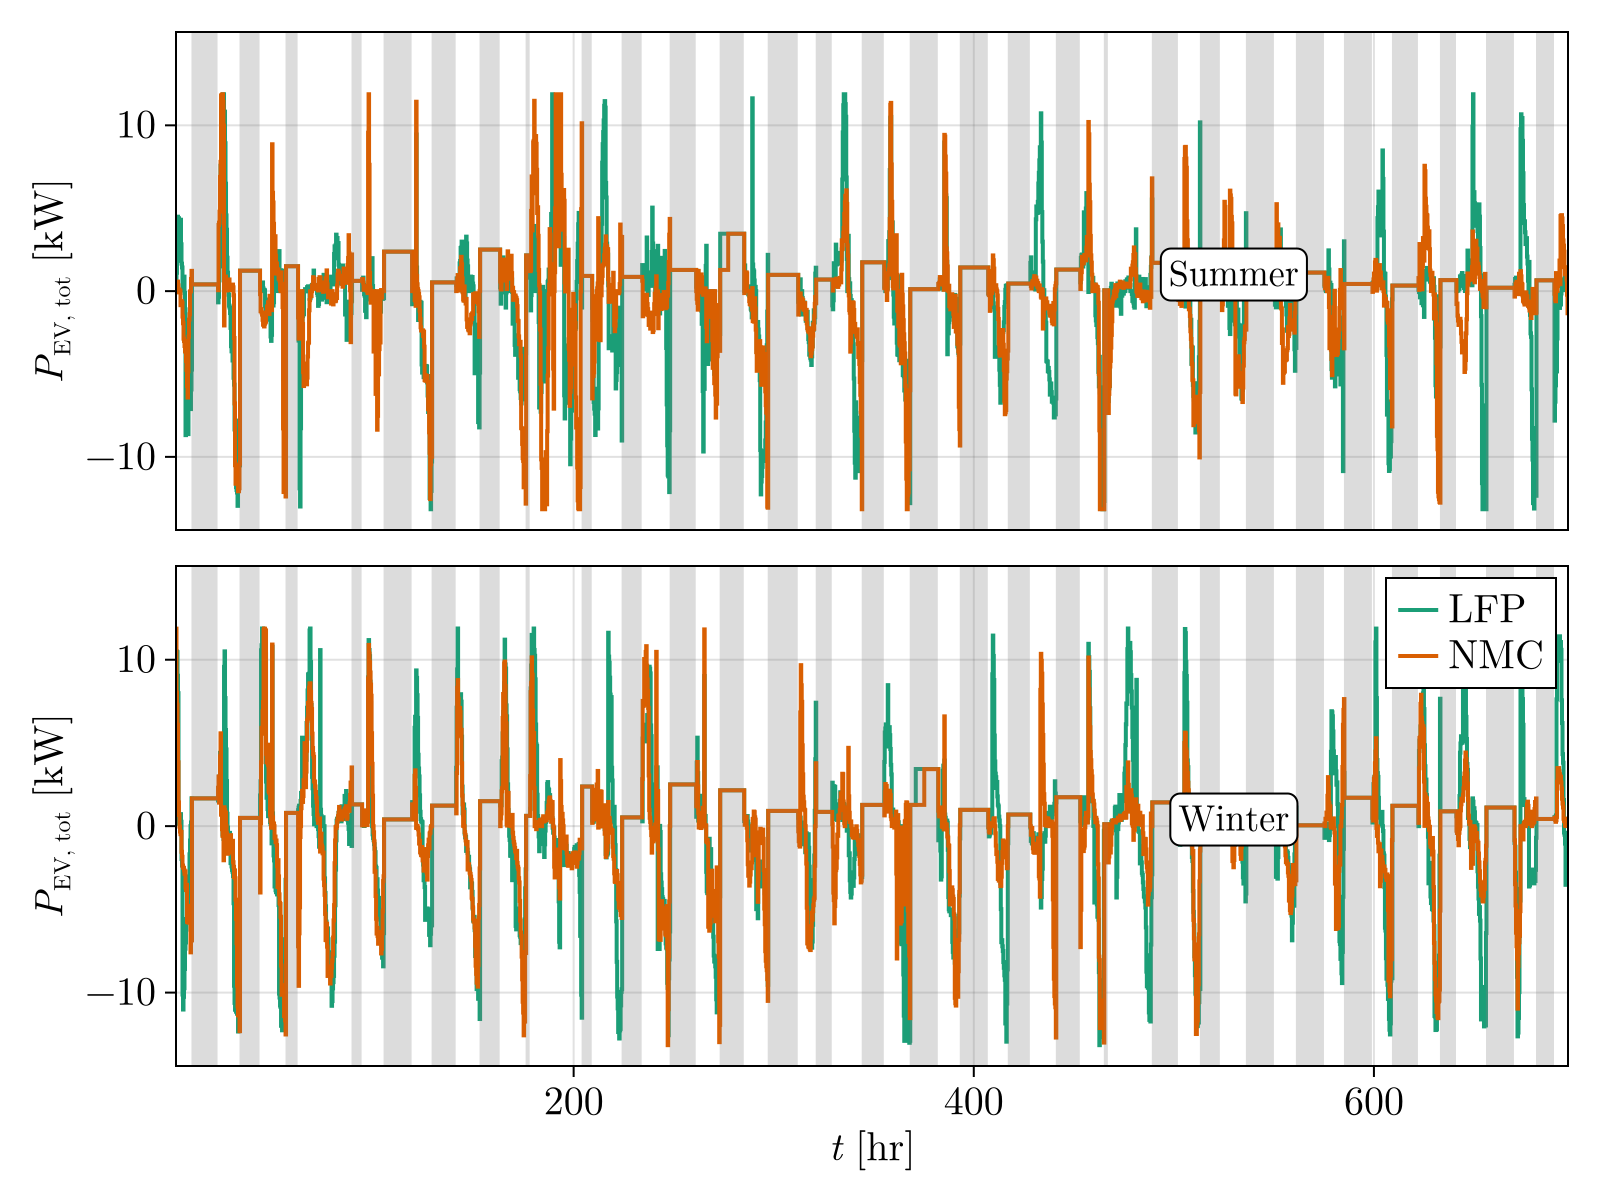

In [7]:
label = L"$P_{\textrm{EV, tot}}$ [kW]"
P_key = "PevTot[1]"; filename="CS2_Pev_LFPvsNMC.pdf"
create_Pfig(results_DA, P_key, label; backend="CairoMakie", filename=folder*filename)

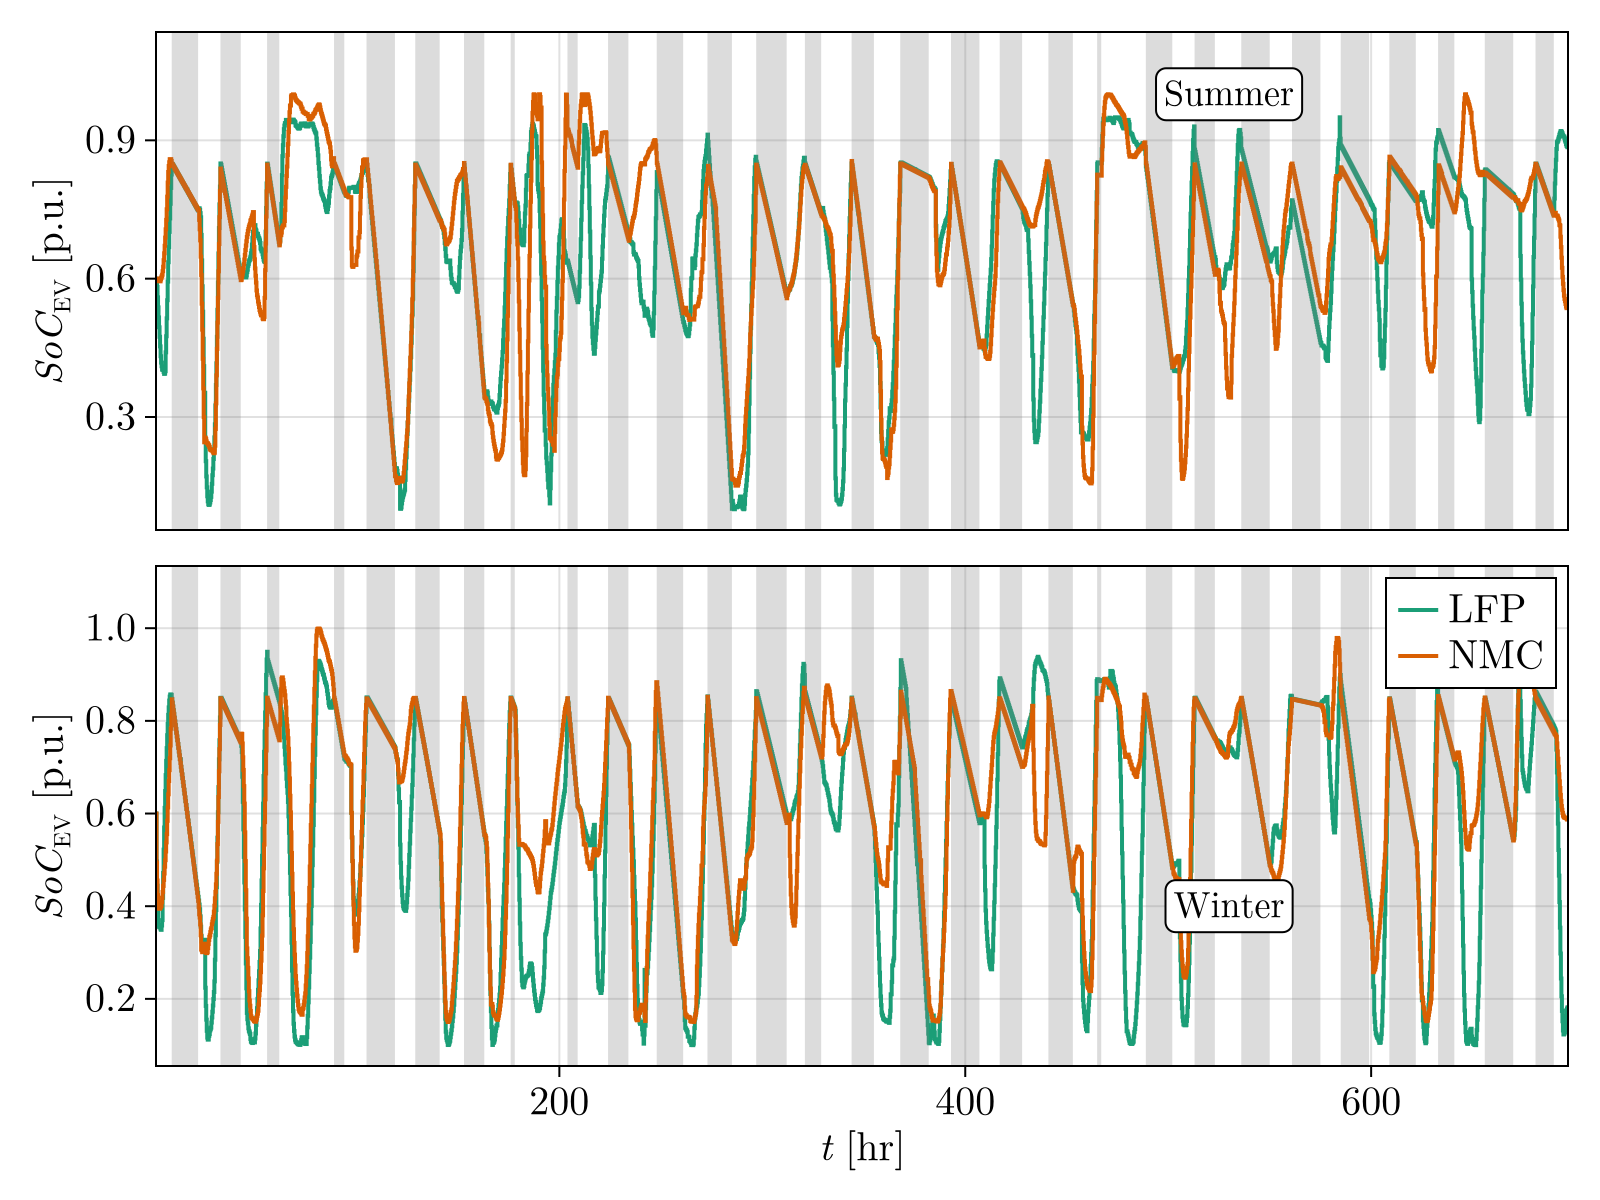

In [8]:
folder= "../images/AppEnergy/cs2/"; # relative path to the
label = L"$SoC_{\textrm{EV}}$ [p.u.]"
P_key = "SoCev[1]"; filename="CS2_SoCev_LFPvsNMC.pdf"
create_Pfig(results_DA, P_key, label; backend="CairoMakie", filename=folder*filename)

### <a id='toc2_1_3_'></a>[TESS](#toc0_)

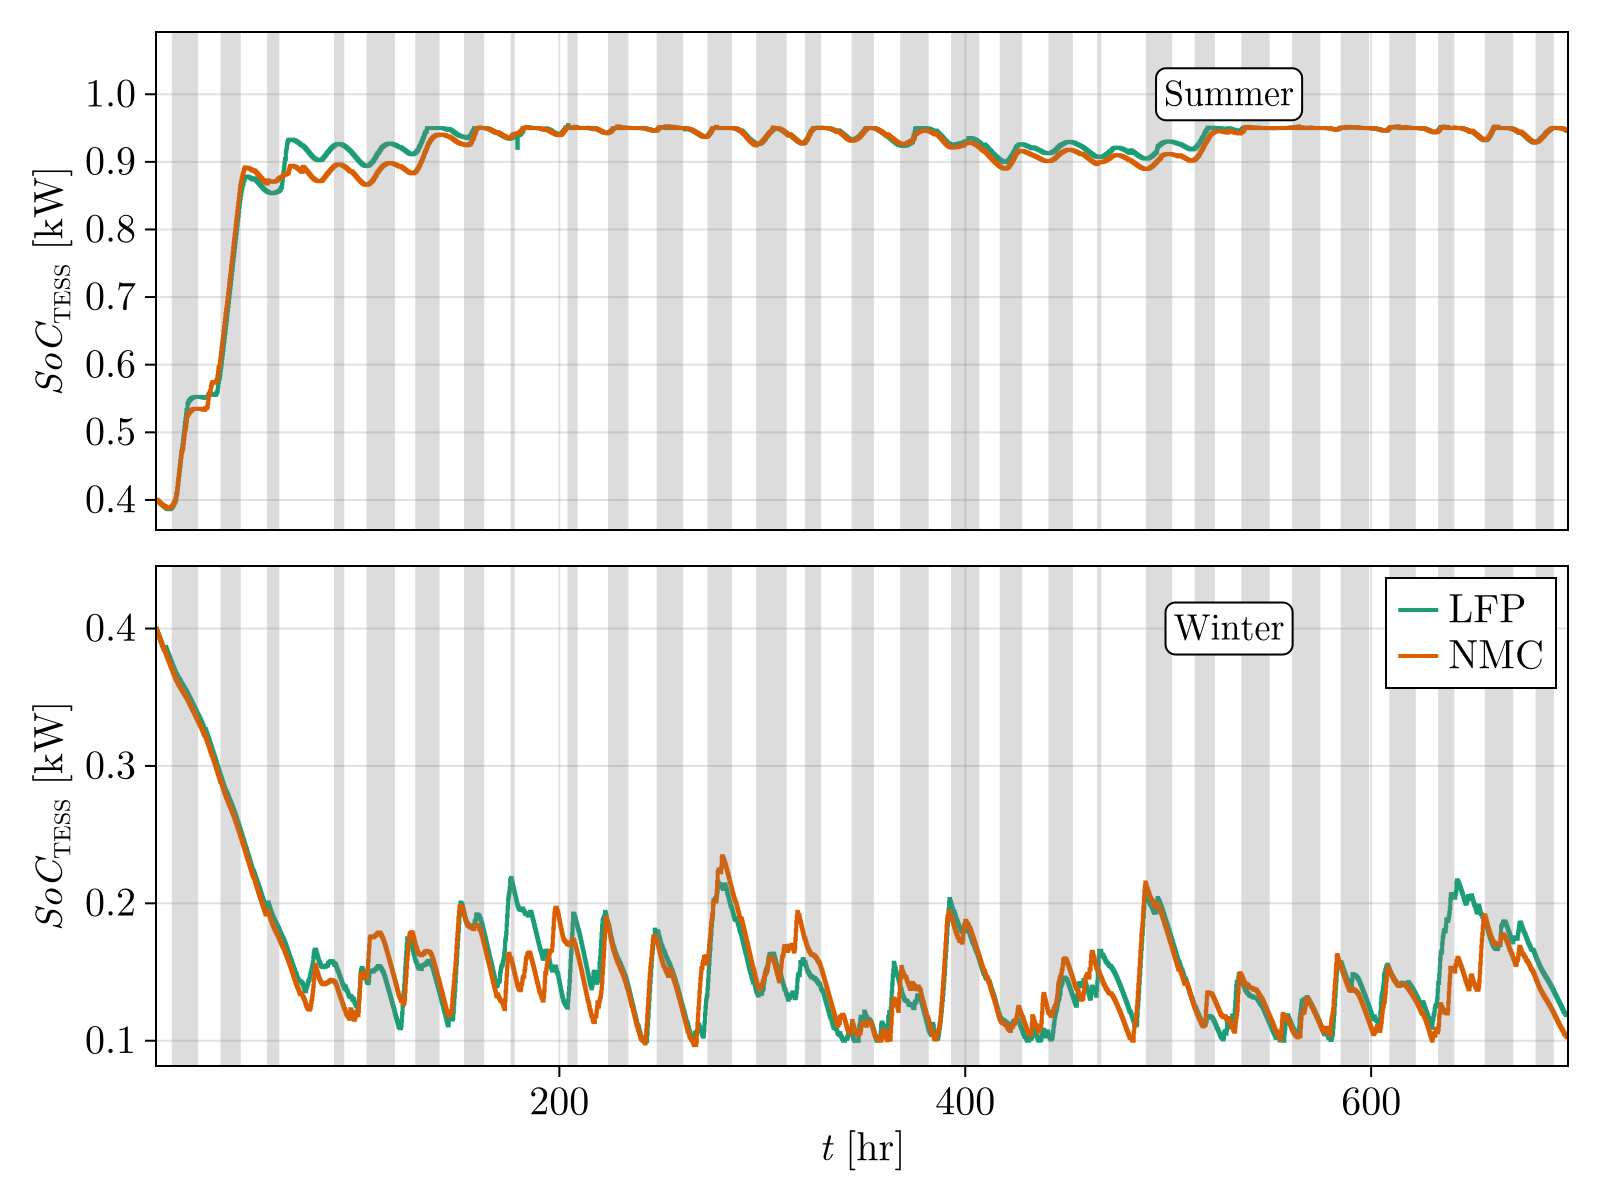

In [9]:
label = L"$SoC_{\textrm{TESS}}$ [kW]"
P_key = "SoCtess"; filename="CS2_SoCtess_LFPvsNMC.pdf"
create_Pfig(results_DA, P_key, label; backend="CairoMakie", filename=folder*filename)

### <a id='toc2_1_4_'></a>[Grid](#toc0_)

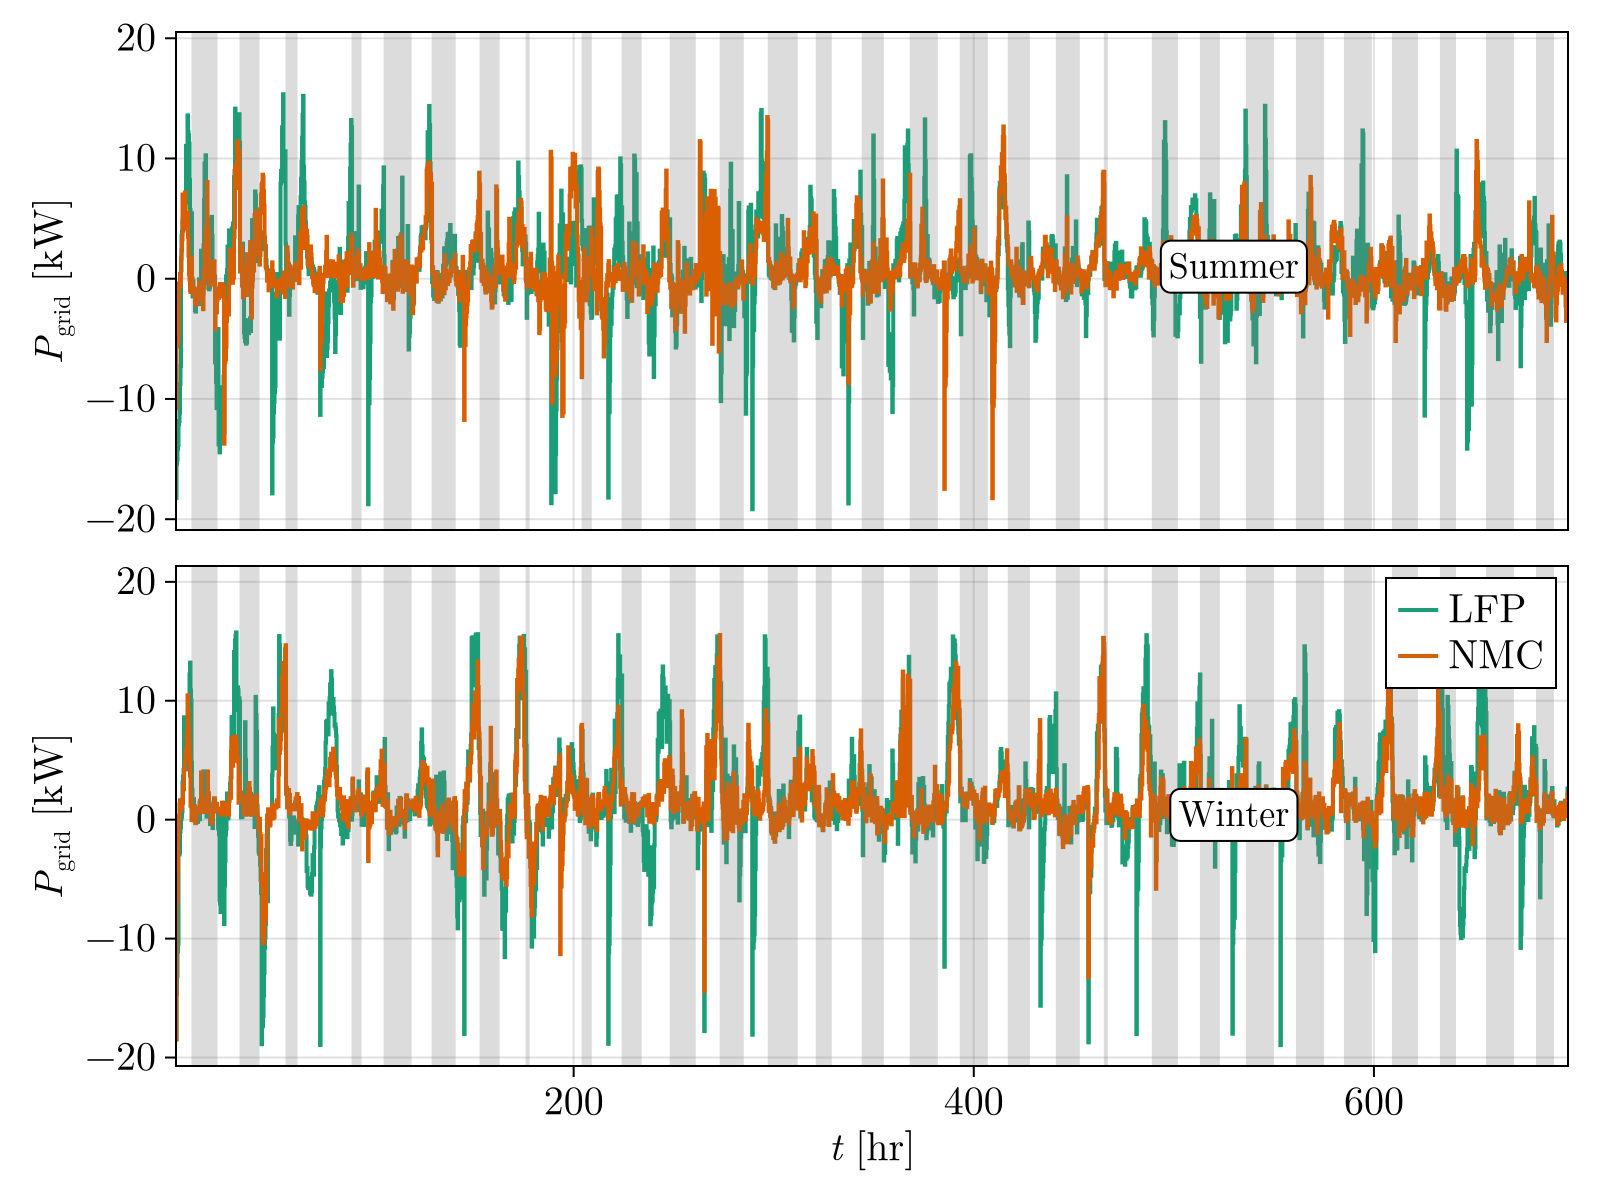

In [9]:
label=L"$P_{\textrm{grid}}$ [kW]"
P_key = "Pg";filename="CS2_Pg_LFPvsNMC.pdf"
create_Pfig(results_DA, P_key, label; backend="CairoMakie", filename=folder*filename)

## <a id='toc2_2_'></a>[2D Histograms](#toc0_)

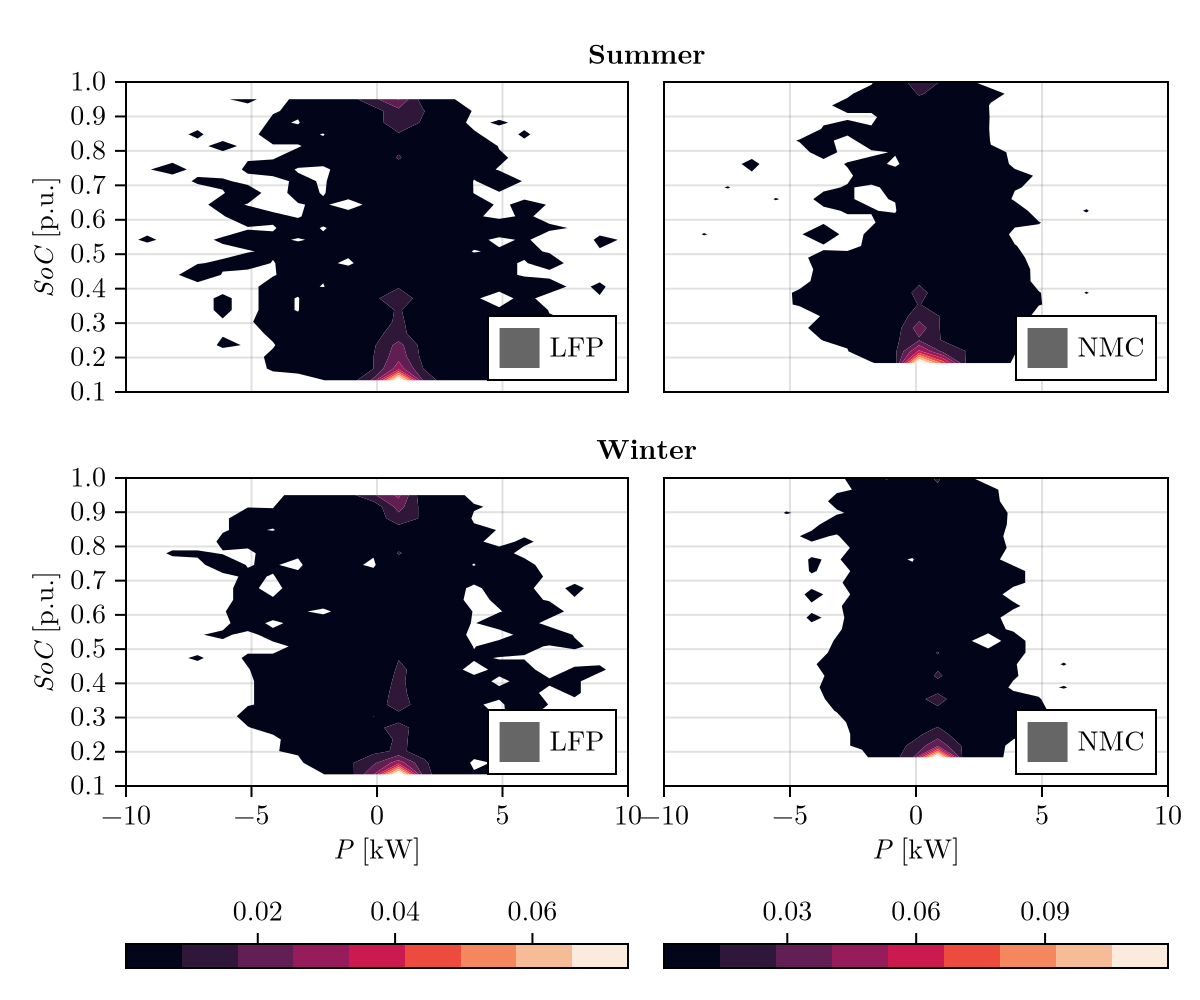

In [10]:
create_SPfig(results_DA, "bess";
            backend="CairoMakie", filename=folder*"CS2_SPbess_LFPvsNMC.pdf",
            cmaps=:seaborn_rocket_gradient,
            lims=([-10.0, 10.0], [0.1, 1.0]),
            nb = 25,
            )

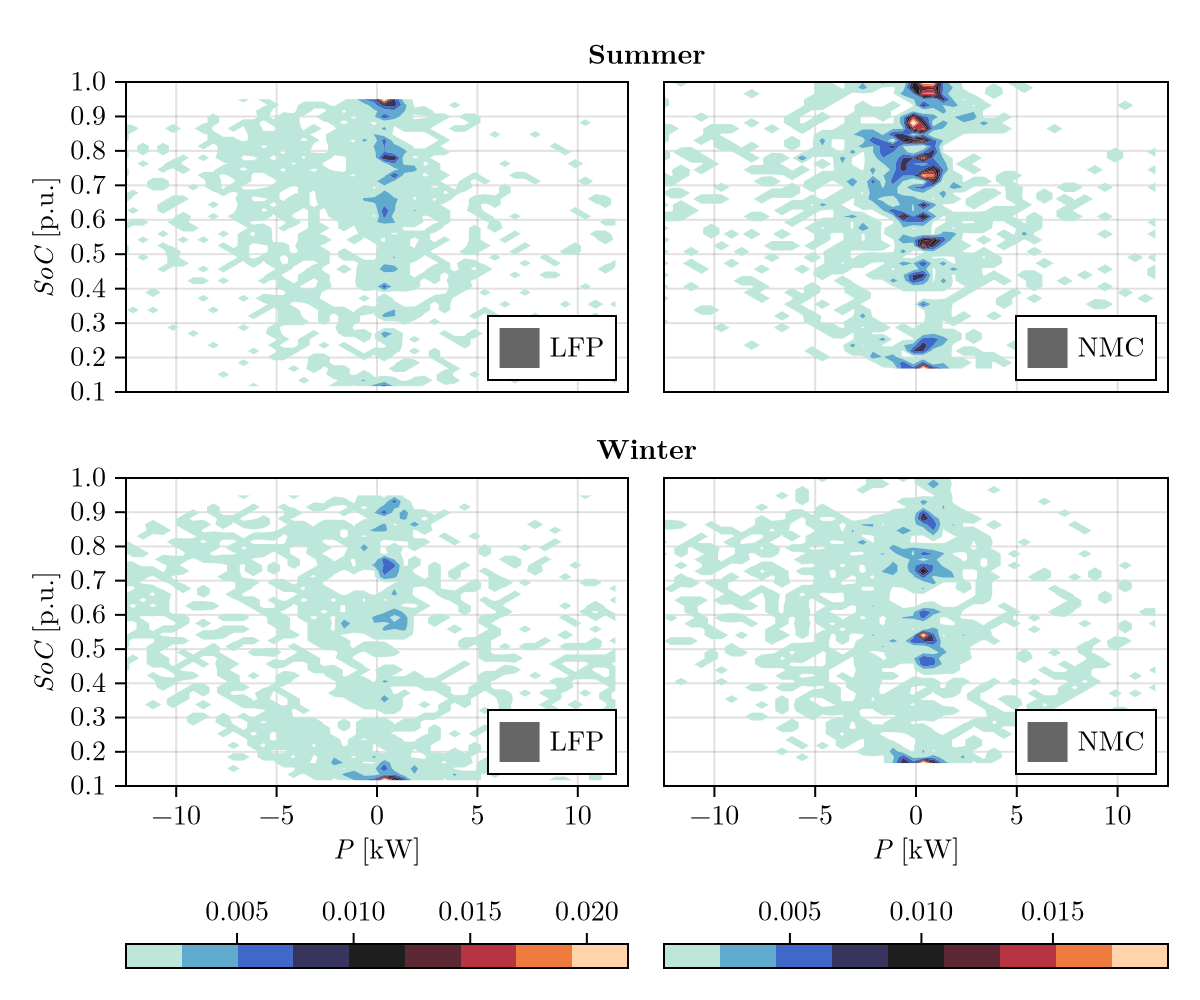

In [11]:
create_SPfig(results_DA, "ev[1]";
            backend="CairoMakie", filename=folder*"CS2_SPev_LFPvsNMC.pdf",
            cmaps=:seaborn_icefire_gradient,
            lims=([-12.5, 12.5], [0.1, 1.0])
            )

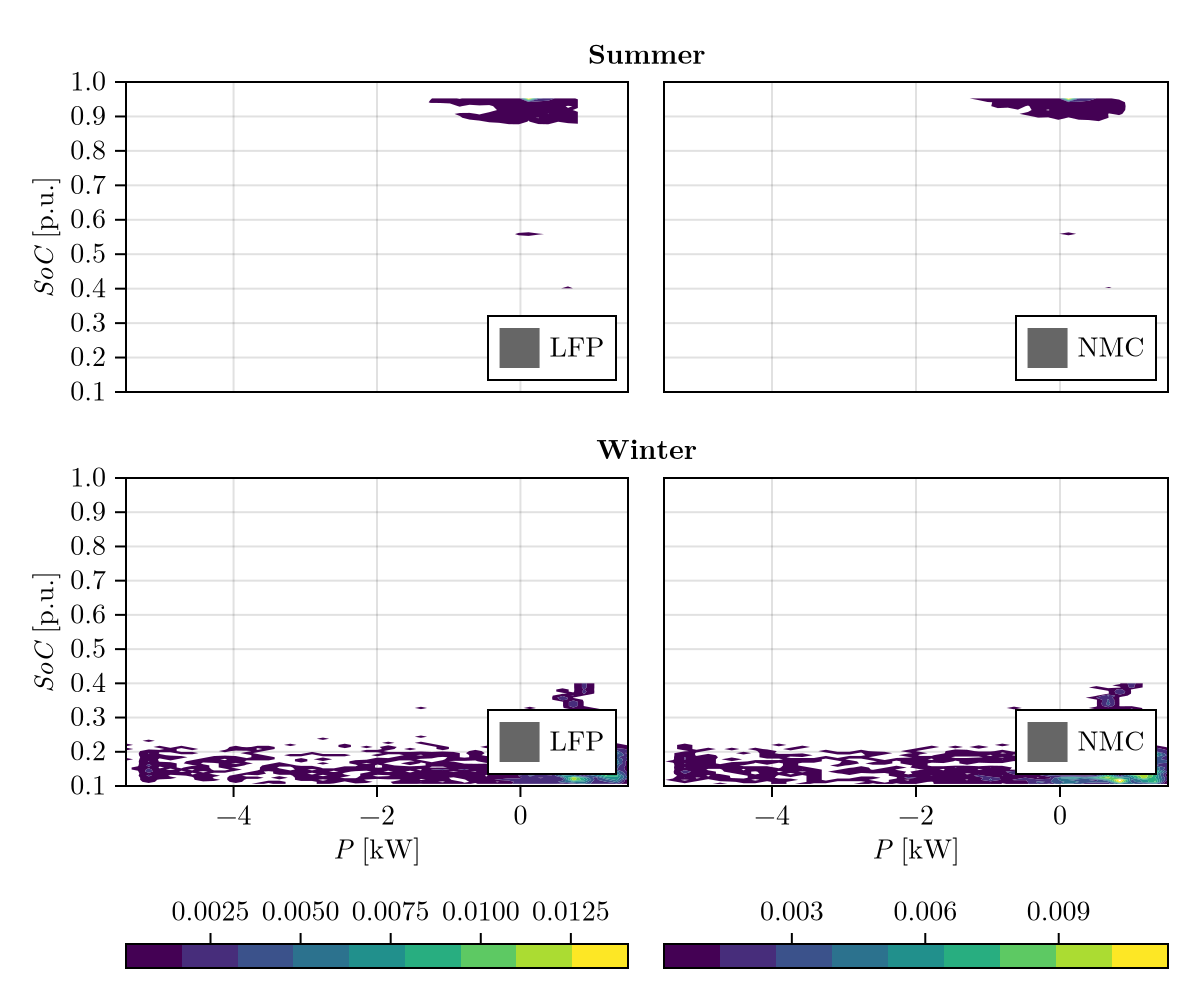

In [30]:
create_SPfig(results_DA, "tess";
            backend="CairoMakie", filename=folder*"CS2_SPev_LFPvsNMC.pdf",
            cmaps=:viridis,
            lims=([-5.5, 1.5], [0.1, 1.0]),
            )

## <a id='toc2_3_'></a>[Degradation analysis](#toc0_)

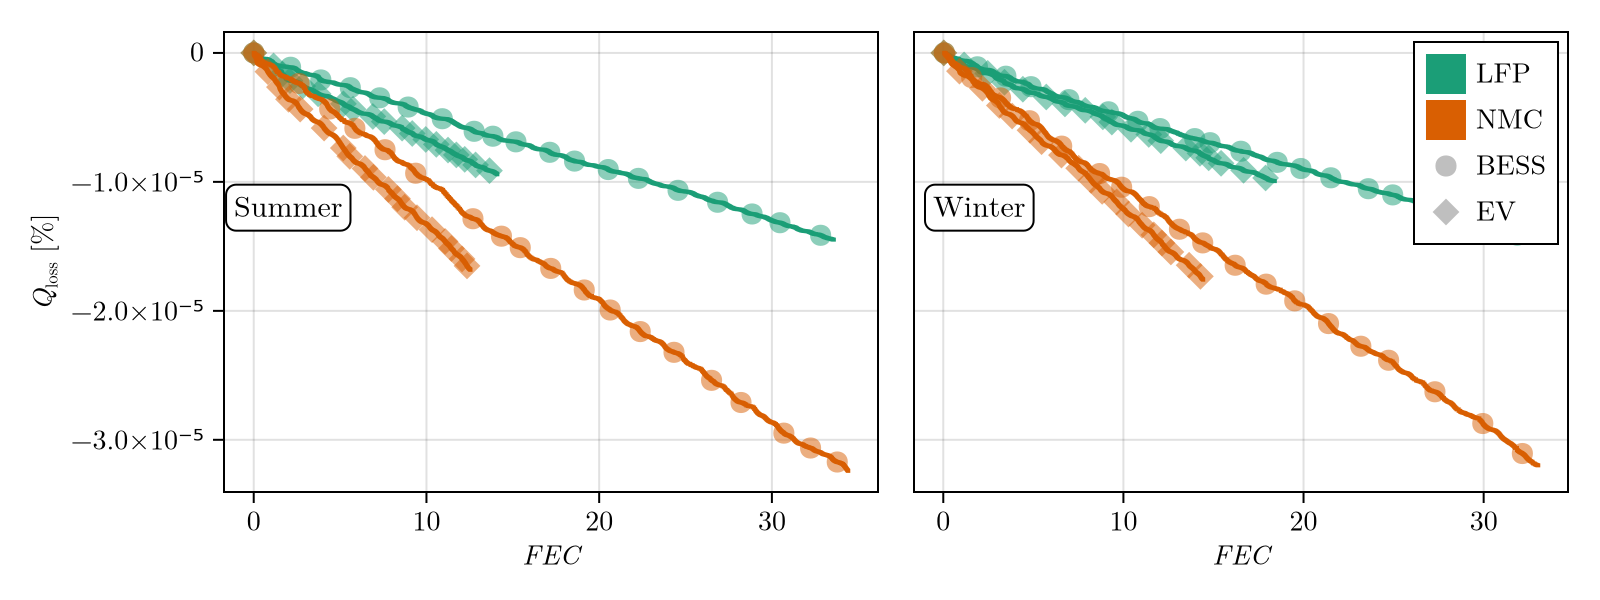

In [12]:
folder = "../images/AppEnergy/cs2/"
create_FECQlossfig(results_DA; backend="CairoMakie", filename=folder*"CS2_FECQloss_LFPvsNMC.pdf")

## <a id='toc2_4_'></a>[Cost analysis functions](#toc0_)

In [13]:
function calcDailyCost(result, data, s)
    t=result["t"]; # time
    Δt=t[2]-t[1]; # time step [s]
    t0=t[1];
    # make new time window
    it0 = Int((t0/Δt) + 1);
    itend = it0+length(t)-1;
    λbuy = data["grid"].λ[it0:itend,1]; # buy price [€/kWs]
    λsell = data["grid"].λ[it0:itend,2]; # sell price [€/kWs]
    Pgpos = result[:"PgPos"]; # positive grid power
    Pgneg = result[:"PgNeg"]; # negative grid power

    dailyCost = []
    for day ∈ 1:s.steps
        # samples per day
        samples = Int.(length(t) / s.steps);
        # time index for the day
        idt = (1:samples) .+ (day-1)*samples;
        cg = sum(Pgpos[idt].*λbuy[idt] - Pgneg[idt].*λsell[idt]).*Δt;
        push!(dailyCost, cg)
    end
    return dailyCost
end

calcDailyCost (generic function with 1 method)

In [14]:
costSummary_DA = Dict(:summer=>Dict(), :winter=>Dict());
dailyCgrid = Dict(:summer=>Dict(), :winter=>Dict())
Wgrid = 1; Wloss = 1;
W=[Wgrid 1000 Wloss 1000];
cells = ["A123", "SYNSANYO"];
# for season ∈ [:summer, :winter]
for season ∈ keys(results_DA)
    for (c, cath) ∈ enumerate(keys(results_DA[season]))
        # res_vector = results_DA[season][Symbol(cath)]
        # results = concatResultsRH(res_vector; typeOpt="day-ahead")
        results = results_DA[season][Symbol(cath)]
        t0 = results["t"][1]; 
        Δt = results["t"][2] - results["t"][1];
        s=modelSettings(nEV=1, t0=t0,Tw=48-1/4, Δt=Δt, steps=29, costWeights=W,
                season=String(season), profType="monthly", loadType="GV", year=2023);
        inputs = build_data(; nEV=1, 
            season=String(season),
            profType=s.profType,
            loadType=s.loadType,
            year=s.year,
            cellID=cells[c])
        inputs["grid"].λ /= 1000;
        inputs["grid"].λ /= 3600;
        costSummary_DA[season][cath] = calcFullObj(results, inputs, s);
        dailyCgrid[season][cath] = calcDailyCost(results, inputs, s);
    end
end

In [15]:
# put the final grid costs in a DataFrame with columns being the seasons and rows the cathodes
Cg_df = DataFrame(cathode = String[], summer=Float64[], winter=Float64[])
for (c, cath) ∈ enumerate(keys(costSummary_DA[:summer]))
    push!(Cg_df, [String(cath), costSummary_DA[:summer][cath].wCgrid[end]/Wgrid, costSummary_DA[:winter][cath].wCgrid[end]/Wgrid])
end
Cg_df

Row,cathode,summer,winter
,String,Float64,Float64
1,LFP,60.8679,108.013
2,NMC,57.6265,109.888


In [16]:
# put the final grid costs in a DataFrame with columns being the seasons and rows the cathodes
Qloss_df = DataFrame(cathode = String[], summer=Float64[], winter=Float64[])
for (c, cath) ∈ enumerate(keys(costSummary_DA[:summer]))
    push!(Qloss_df, [String(cath), costSummary_DA[:summer][cath].wCloss[end]/Wloss/1.2*1e3,
                                 costSummary_DA[:winter][cath].wCloss[end]/Wloss/1.2*1e3])
end
Qloss_df # in mAh

Row,cathode,summer,winter
,String,Float64,Float64
1,LFP,237.948,246.347
2,NMC,343.16,351.662


In [17]:
Qloss_df[!,:summer][2] / Qloss_df[!,:summer][1]

1.4421627328982254

In [18]:
Qloss_df[!,:winter][2] / Qloss_df[!,:winter][1]

1.4275065560389906